In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import utils as uti

In [2]:
print(uti.__file__)
print(dir(uti))

/home/jovyan/work/credit-risk/code/utils/__init__.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'calculate_wald_statistics', 'corr_crit', 'forward_select_auc', 'model', 'plot_event_cat', 'plot_event_num', 'plot_logit_marginal_effect']


# import data

In [3]:
df = pd.read_pickle("../data/00_df_train.pkl")
df_test = pd.read_pickle("../data/00_df_test.pkl")

In [4]:
print(df.shape)
print(df_test.shape)

(800, 21)
(200, 21)


In [5]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits_at_bank,job,liable_persons,telephone,foreign_worker,bad
828,<0 DM,36,current credit paid,used car,8335,unknown/no savings,>=7 years,3,male single,none,...,unknown/no property,47,none,free,1,skilled employee/official,1,none,yes,1
997,no account,12,current credit paid,radio/TV,804,<100 DM,>=7 years,4,male single,none,...,car/other property,38,none,own,1,skilled employee/official,1,none,yes,0
148,<0 DM,36,critical/other credit,furniture/equipment,5371,<100 DM,1-4 years,3,male single,guarantor,...,life insurance/building society,28,none,own,2,skilled employee/official,1,none,yes,0
735,0-200 DM,36,bank credit paid,appliances,3990,unknown/no savings,<1 year,3,female married/divorced,none,...,unknown/no property,29,bank,own,1,unemployed/unskilled nonresident,1,none,yes,0
130,0-200 DM,48,current credit paid,new car,8487,unknown/no savings,4-7 years,1,female married/divorced,none,...,car/other property,24,none,own,1,skilled employee/official,1,none,yes,0


In [6]:
df.groupby('bad').size()

bad
0    560
1    240
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 828 to 749
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   800 non-null    str  
 1   duration_months           800 non-null    int64
 2   credit_history            800 non-null    str  
 3   purpose                   800 non-null    str  
 4   credit_amount             800 non-null    int64
 5   savings_account_bonds     800 non-null    str  
 6   employment_since          800 non-null    str  
 7   installment_rate_percent  800 non-null    int64
 8   personal_status_sex       800 non-null    str  
 9   other_debtors_guarantors  800 non-null    str  
 10  residence_since           800 non-null    int64
 11  property                  800 non-null    str  
 12  age_years                 800 non-null    int64
 13  other_installment_plans   800 non-null    str  
 14  housing                   800 non-null    str  
 15  exi

# correlation pre transform

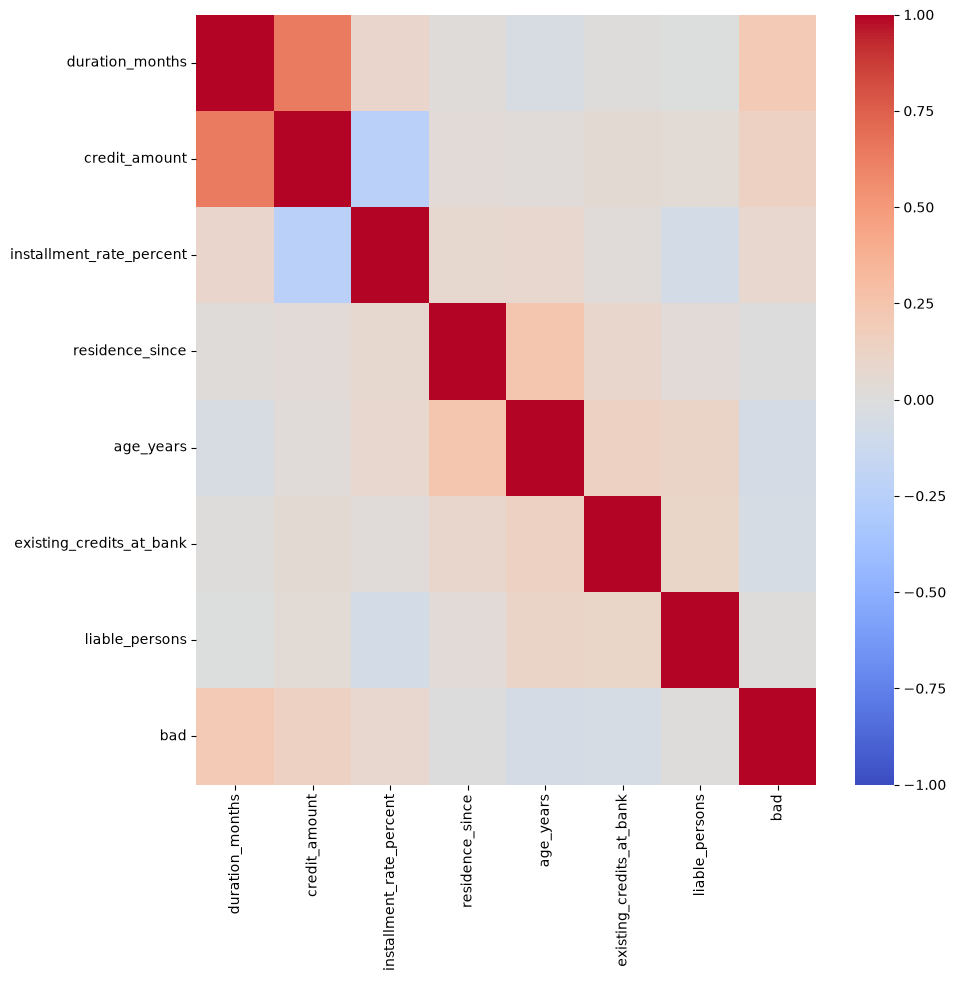

In [8]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    correlation_matrix,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

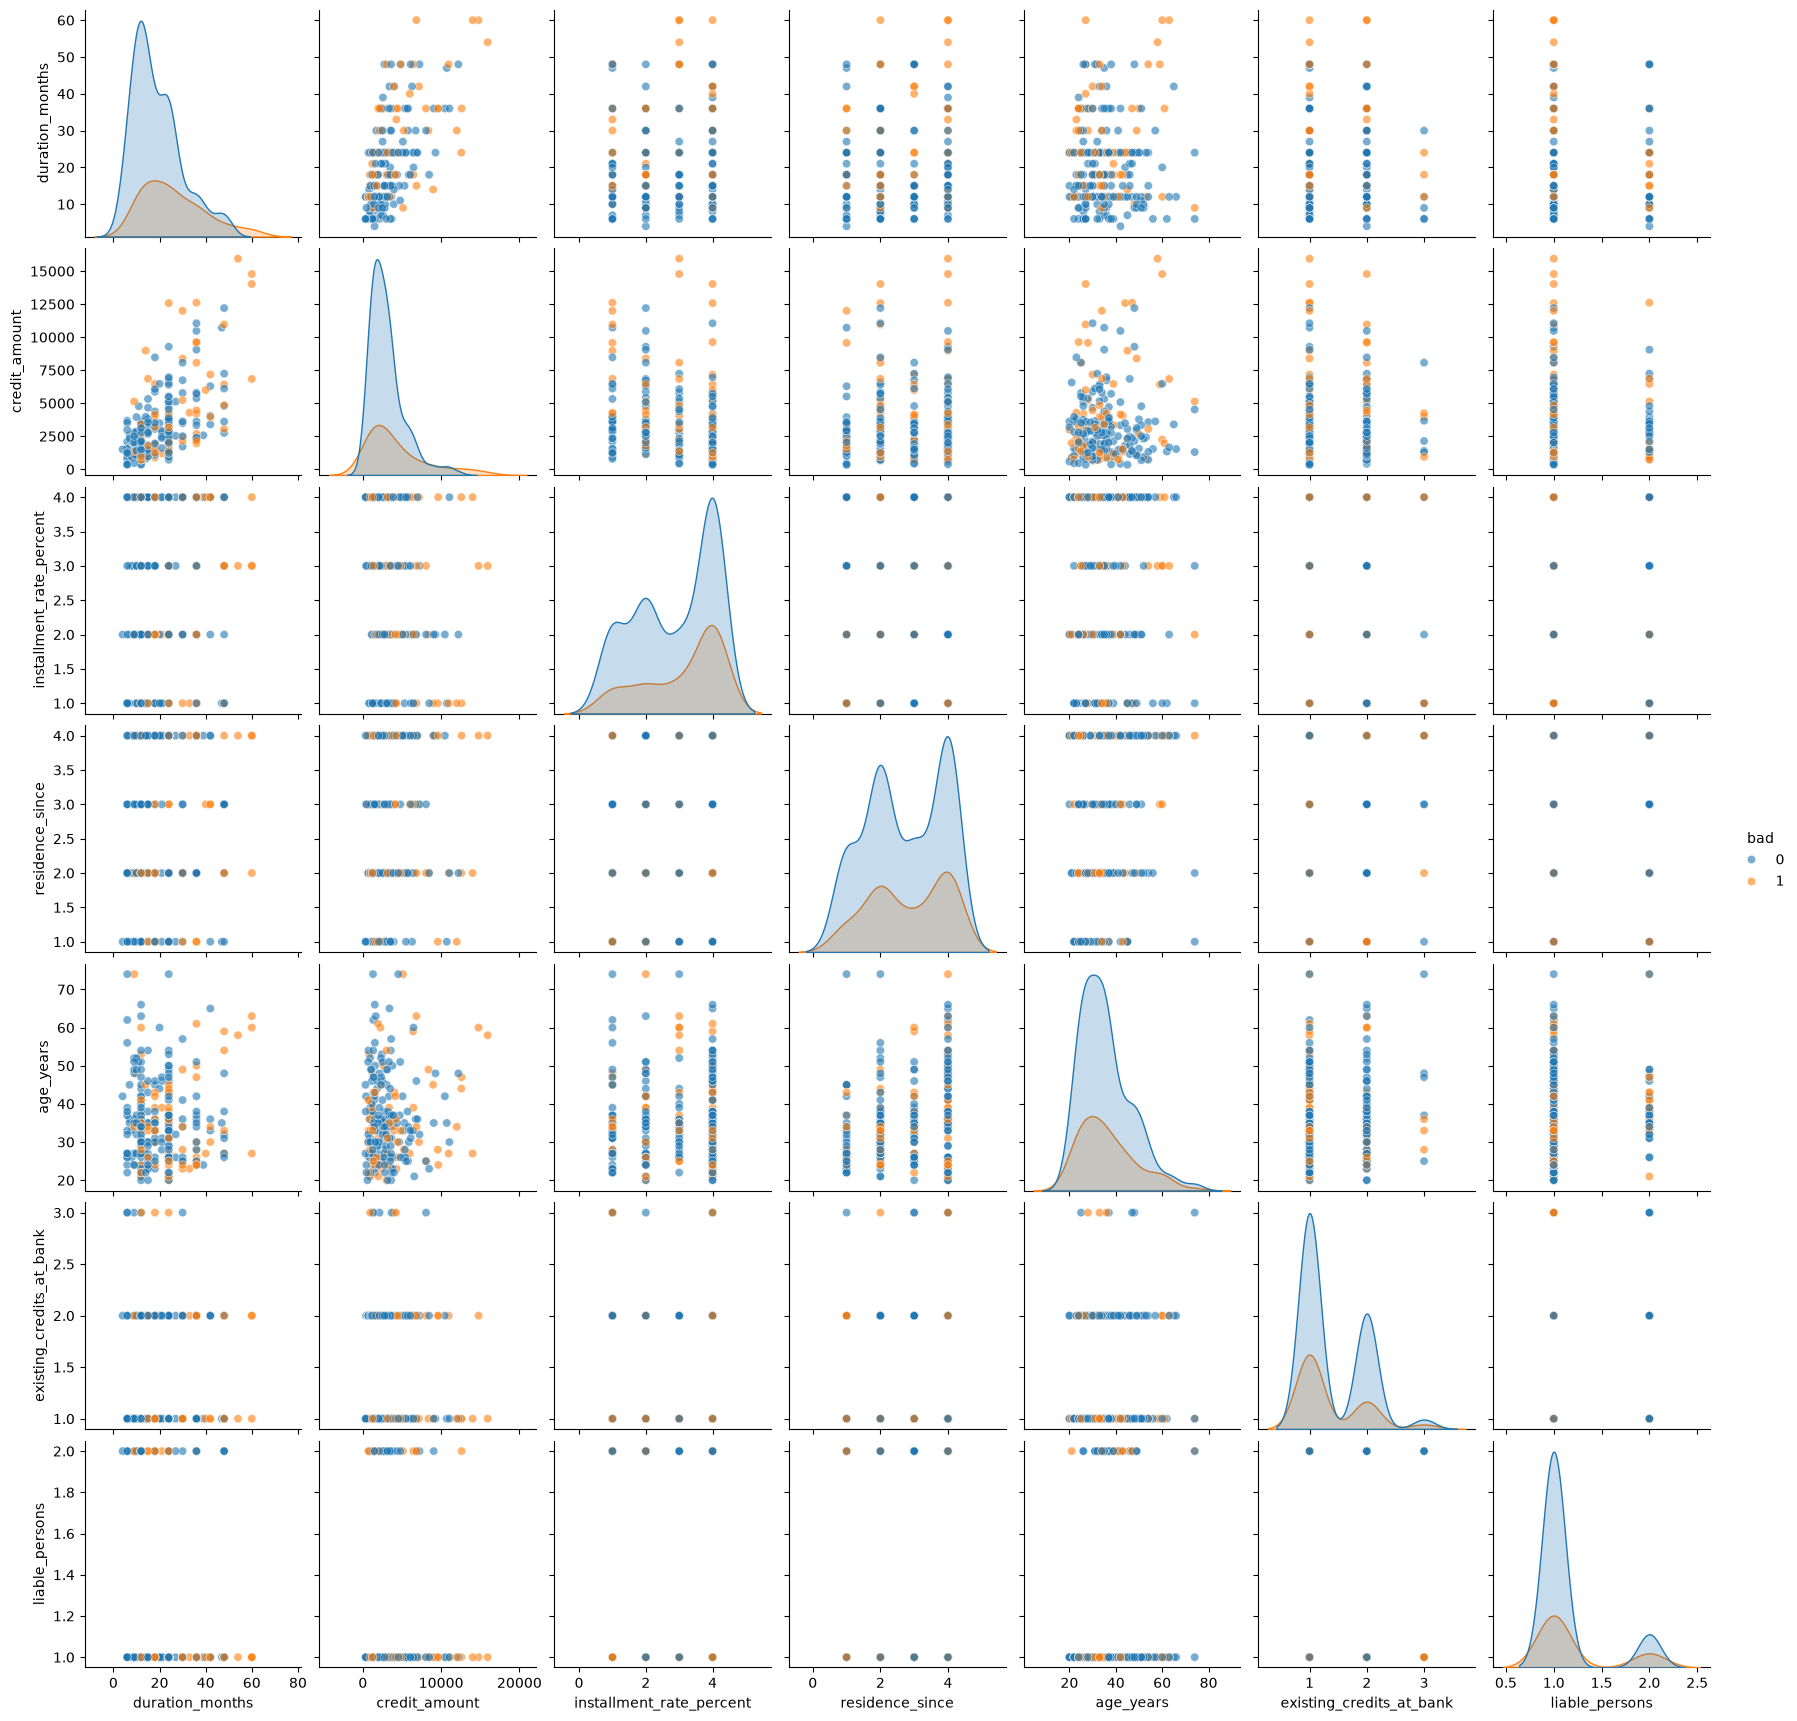

In [9]:
sns.pairplot(
    df.sample(n=250, random_state=42).reset_index(drop=True),
    hue="bad",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

# domographics

In [10]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

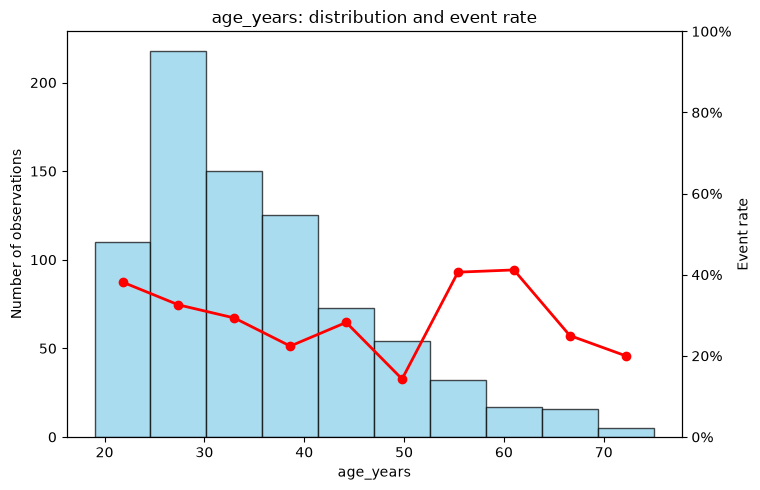

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'age_years: distribution and event rate'}, xlabel='age_years', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [11]:
uti.plot_event_num(
    df=df,
    column_names=["age_years"],
    event_column="bad",
    n_bins=10
)

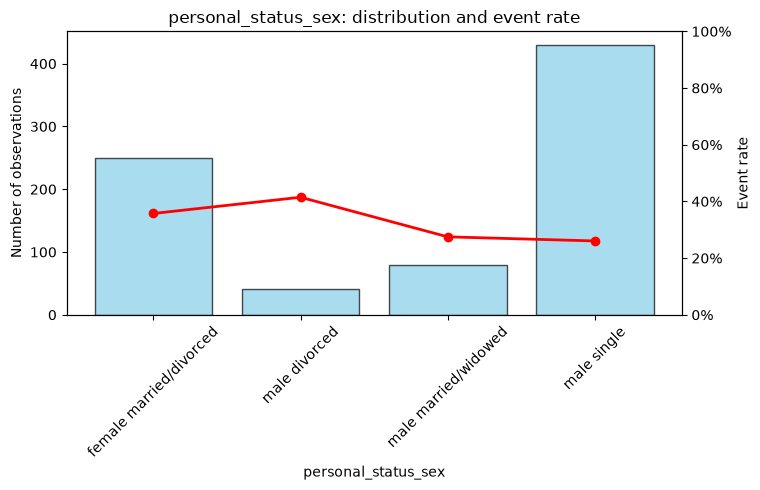

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'personal_status_sex: distribution and event rate'}, xlabel='personal_status_sex', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [12]:
uti.plot_event_cat(
    df,
    ['personal_status_sex'],
    event_column="bad"
)

# weight of evidence

In [13]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

In [14]:
num_cols = df.select_dtypes(include='number').columns.tolist()
excl = ['bad','age_years']

num_cols = [item for item in num_cols if item not in excl]
num_cols

['duration_months',
 'credit_amount',
 'installment_rate_percent',
 'residence_since',
 'existing_credits_at_bank',
 'liable_persons']

In [15]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
excl = ['personal_status_sex']

cat_cols = [item for item in cat_cols if item not in excl]
cat_cols

['checking_account_status',
 'credit_history',
 'purpose',
 'savings_account_bonds',
 'employment_since',
 'other_debtors_guarantors',
 'property',
 'other_installment_plans',
 'housing',
 'job',
 'telephone',
 'foreign_worker']

In [16]:
import toad

combiner = toad.transform.Combiner()

combiner.fit(
    df[num_cols + cat_cols],
    df['bad'],
    method="chi",
    min_samples=0.05
)

In [17]:
X_train_bins = combiner.transform(df[num_cols + cat_cols])
X_test_bins = combiner.transform(df_test[num_cols + cat_cols])

In [18]:
X_train_bins.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
828,6,4,2,3,0,0,3,1,0,2,1,0,3,0,2,0,1,0
997,2,0,3,3,0,0,0,1,0,4,1,0,2,0,0,0,1,0
148,6,4,2,1,1,0,3,0,1,4,2,0,1,0,0,0,1,0
735,6,3,2,1,0,0,2,2,1,2,4,0,3,1,0,1,1,0
130,6,4,0,1,0,0,2,1,1,2,0,0,2,0,0,0,1,0


In [19]:
bin_rules = combiner.export()

print(bin_rules)

{'duration_months': [9, 12, 13, 16, 21, 36], 'credit_amount': [1382, 1778, 2603, 4057], 'installment_rate_percent': [2, 3, 4], 'residence_since': [2, 3, 4], 'existing_credits_at_bank': [2], 'liable_persons': [2], 'checking_account_status': [['no account'], ['>=200 DM'], ['0-200 DM'], ['<0 DM']], 'credit_history': [['critical/other credit'], ['past payment delays', 'current credit paid'], ['bank credit paid', 'no credit/all paid']], 'purpose': [['used car', 'retraining', 'radio/TV'], ['appliances', 'furniture/equipment', 'business', 'other', 'new car', 'repairs', 'education']], 'savings_account_bonds': [['>=1000 DM'], ['500-1000 DM'], ['unknown/no savings'], ['100-500 DM'], ['<100 DM']], 'employment_since': [['4-7 years'], ['>=7 years'], ['1-4 years'], ['unemployed'], ['<1 year']], 'other_debtors_guarantors': [['guarantor', 'none', 'co-applicant']], 'property': [['real estate'], ['life insurance/building society'], ['car/other property'], ['unknown/no property']], 'other_installment_pla

In [20]:
woe_transformer = toad.transform.WOETransformer()

woe_transformer.fit(
    X_train_bins,
    df['bad']
)


In [21]:
X_train_woe = woe_transformer.transform(X_train_bins)
X_test_woe = woe_transformer.transform(X_test_bins)

In [22]:
X_train_woe.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
828,0.713766,0.525398,-0.063573,0.013072,0.078472,-0.011364,0.765060,0.101425,-0.494364,-0.762140,-0.187599,0.0,0.685657,-0.149123,0.470820,-0.048159,0.074108,0.0
997,-0.143101,0.082177,0.178443,0.013072,0.078472,-0.011364,-1.142737,0.101425,-0.494364,0.290162,-0.187599,0.0,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.0
148,0.713766,0.525398,-0.063573,-0.037517,-0.138150,-0.011364,0.765060,-0.703300,0.258256,0.290162,-0.113329,0.0,-0.005181,-0.149123,-0.200495,-0.048159,0.074108,0.0
735,0.713766,-0.436718,-0.063573,-0.037517,0.078472,-0.011364,0.410580,1.126883,0.258256,-0.762140,0.608406,0.0,0.685657,0.567338,-0.200495,0.233288,0.074108,0.0
130,0.713766,0.525398,-0.274845,-0.037517,0.078472,-0.011364,0.410580,0.101425,0.258256,-0.762140,-0.400846,0.0,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.0


## check bins

In [23]:
# Count the number of final bins for each variable
bin_counts = X_train_woe.nunique(dropna=False)
bin_counts

duration_months             7
credit_amount               5
installment_rate_percent    4
residence_since             4
existing_credits_at_bank    2
liable_persons              2
checking_account_status     4
credit_history              3
purpose                     2
savings_account_bonds       5
employment_since            5
other_debtors_guarantors    1
property                    4
other_installment_plans     2
housing                     3
job                         2
telephone                   2
foreign_worker              1
dtype: int64

In [24]:
valid_features = bin_counts[bin_counts > 1].index.tolist()
dropped_features = bin_counts[bin_counts <= 1].index.tolist()

print("Keeping:", valid_features)
print("Dropping:", dropped_features)


Keeping: ['duration_months', 'credit_amount', 'installment_rate_percent', 'residence_since', 'existing_credits_at_bank', 'liable_persons', 'checking_account_status', 'credit_history', 'purpose', 'savings_account_bonds', 'employment_since', 'property', 'other_installment_plans', 'housing', 'job', 'telephone']
Dropping: ['other_debtors_guarantors', 'foreign_worker']


In [25]:
X_train_woe.drop(columns=dropped_features, inplace=True)
X_test_woe.drop(columns=dropped_features, inplace=True)

In [26]:
X_train_woe = X_train_woe.add_suffix("_woe")
X_test_woe = X_test_woe.add_suffix("_woe")

In [27]:
vars_woe = X_train_woe.columns.tolist()

In [28]:
print(X_train_woe.shape)
print(X_test_woe.shape)

(800, 16)
(200, 16)


In [29]:
print(df.shape)
print(df_test.shape)

(800, 21)
(200, 21)


In [30]:
df = pd.concat(
    [df, X_train_woe],
    axis=1
)

df_test = pd.concat(
    [df_test, X_test_woe],
    axis=1
)


In [31]:
print(df.shape)
print(df_test.shape)

(800, 37)
(200, 37)


In [32]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,checking_account_status_woe,credit_history_woe,purpose_woe,savings_account_bonds_woe,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,job_woe,telephone_woe
828,<0 DM,36,current credit paid,used car,8335,unknown/no savings,>=7 years,3,male single,none,...,0.765060,0.101425,-0.494364,-0.762140,-0.187599,0.685657,-0.149123,0.470820,-0.048159,0.074108
997,no account,12,current credit paid,radio/TV,804,<100 DM,>=7 years,4,male single,none,...,-1.142737,0.101425,-0.494364,0.290162,-0.187599,0.033661,-0.149123,-0.200495,-0.048159,0.074108
148,<0 DM,36,critical/other credit,furniture/equipment,5371,<100 DM,1-4 years,3,male single,guarantor,...,0.765060,-0.703300,0.258256,0.290162,-0.113329,-0.005181,-0.149123,-0.200495,-0.048159,0.074108
735,0-200 DM,36,bank credit paid,appliances,3990,unknown/no savings,<1 year,3,female married/divorced,none,...,0.410580,1.126883,0.258256,-0.762140,0.608406,0.685657,0.567338,-0.200495,0.233288,0.074108
130,0-200 DM,48,current credit paid,new car,8487,unknown/no savings,4-7 years,1,female married/divorced,none,...,0.410580,0.101425,0.258256,-0.762140,-0.400846,0.033661,-0.149123,-0.200495,-0.048159,0.074108


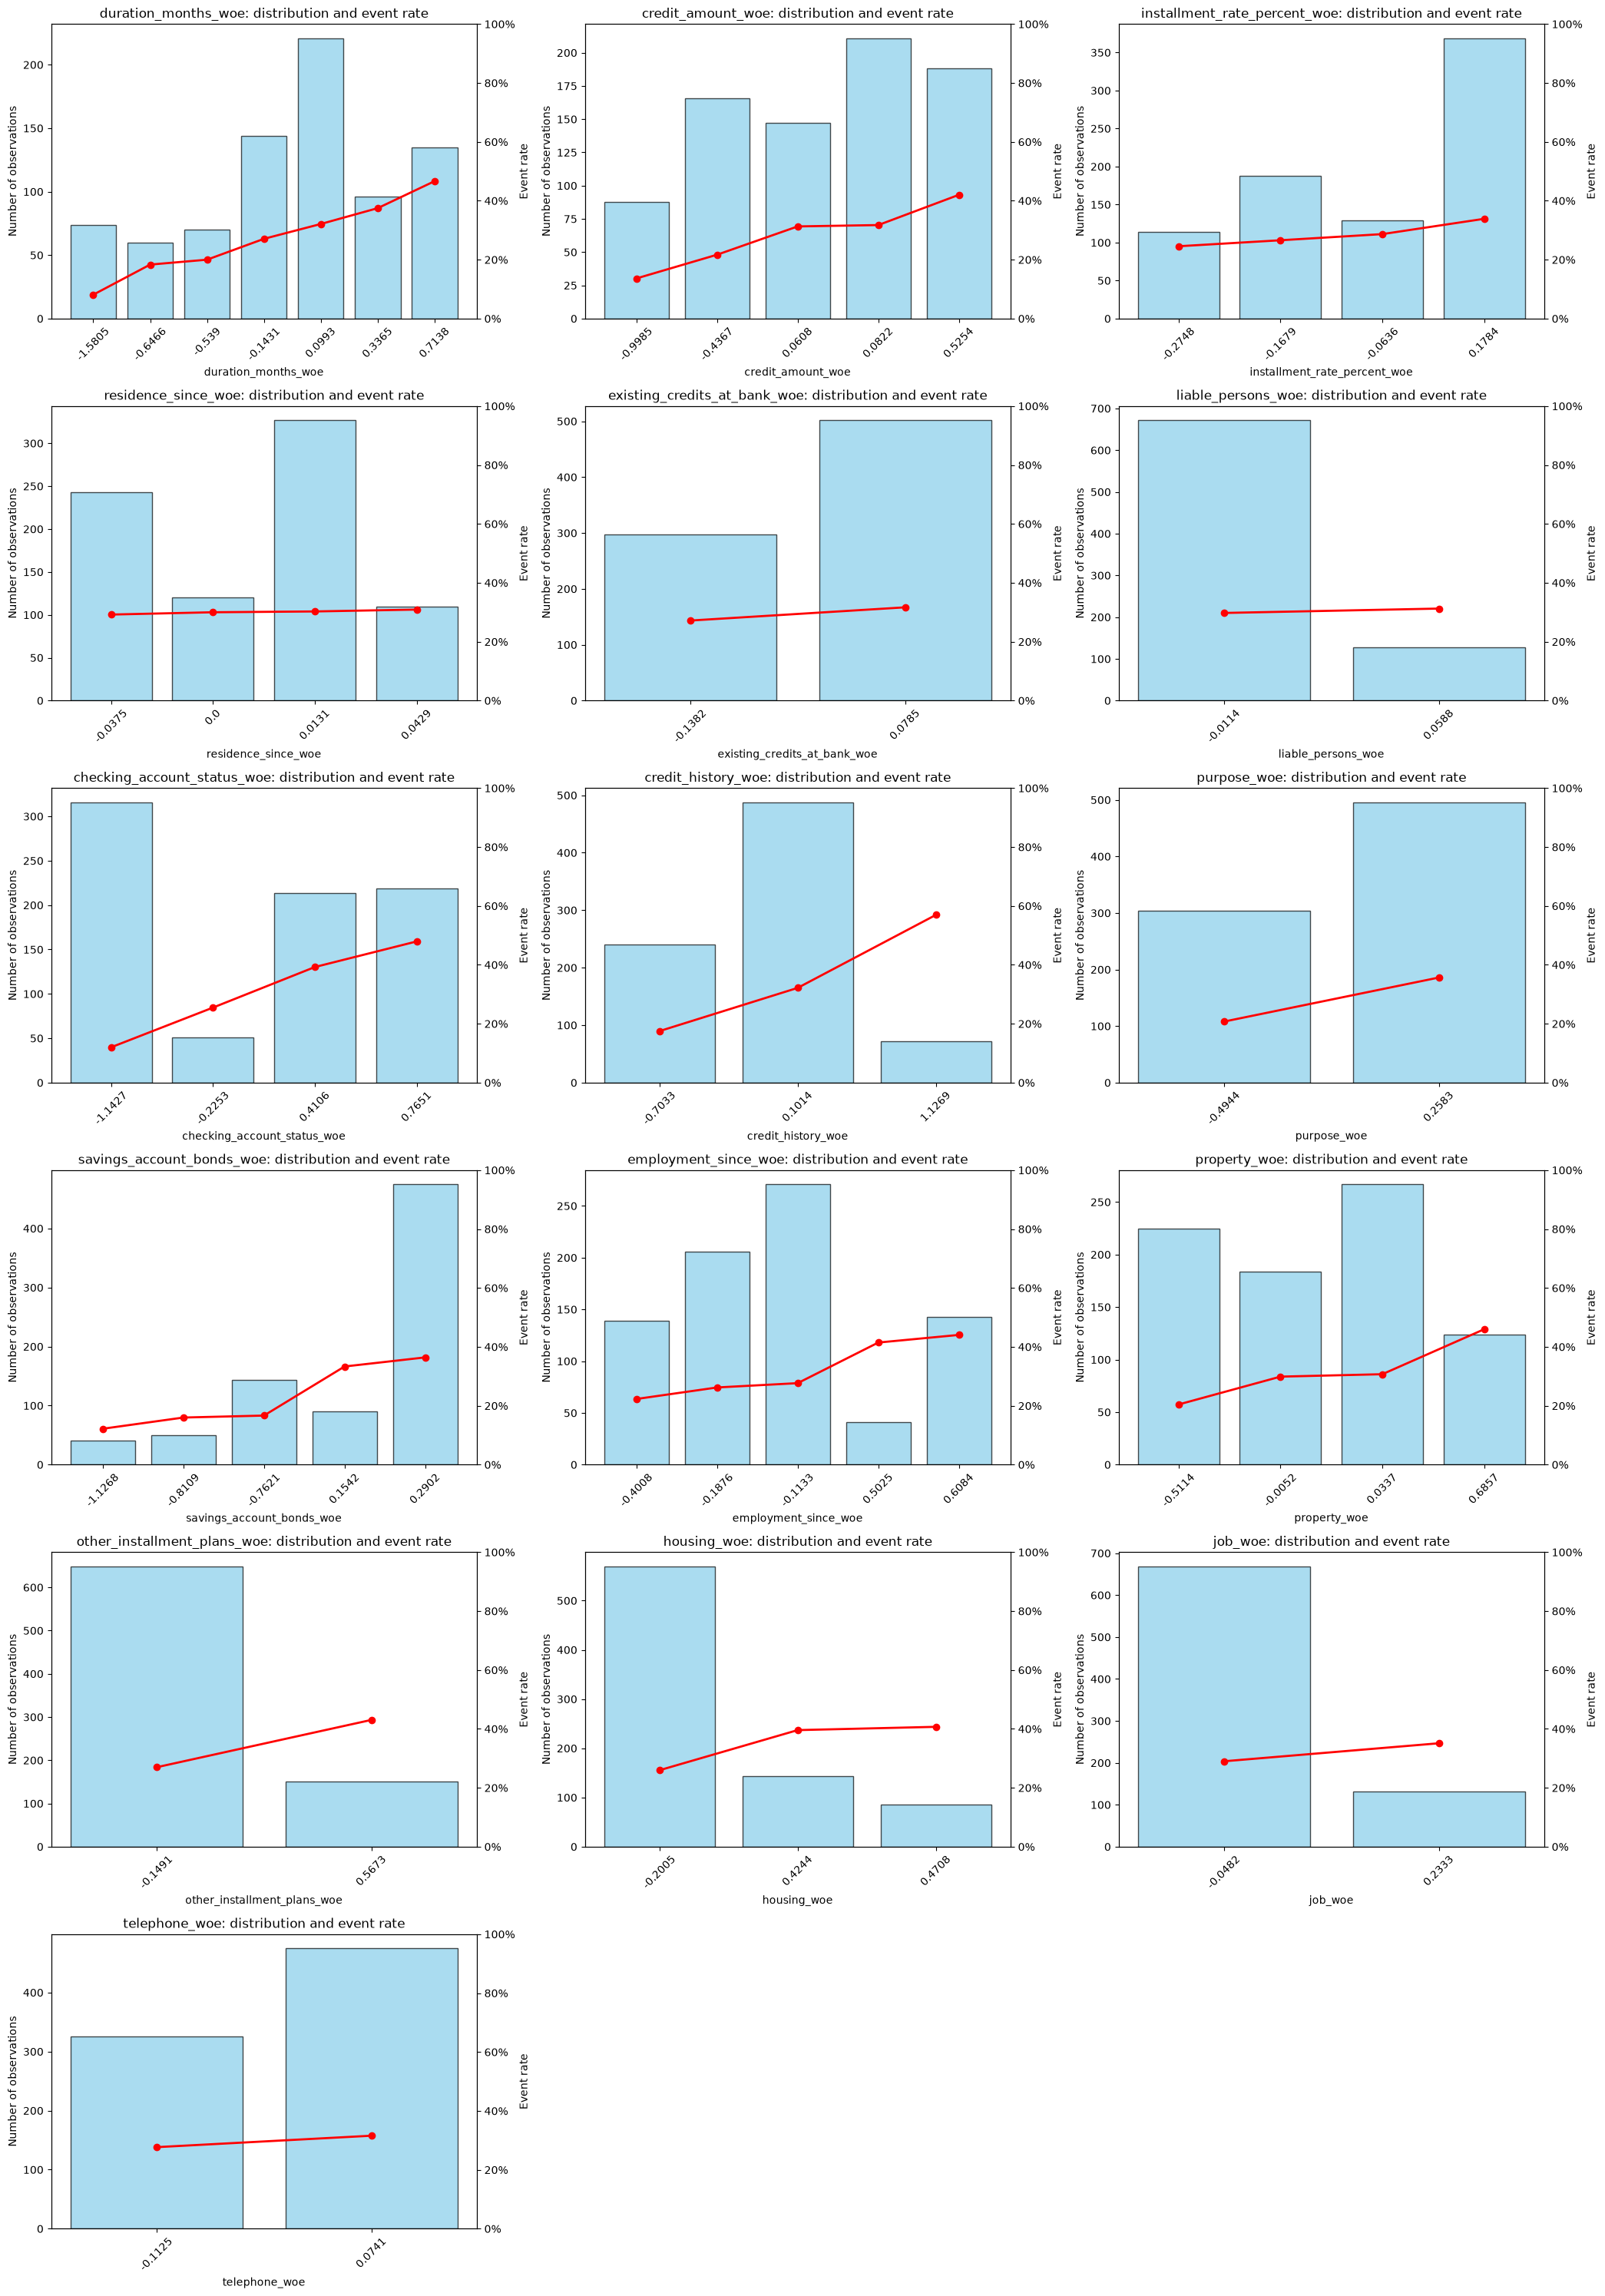

(<Figure size 2100x3000 with 34 Axes>,
 array([<Axes: title={'center': 'duration_months_woe: distribution and event rate'}, xlabel='duration_months_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'credit_amount_woe: distribution and event rate'}, xlabel='credit_amount_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'installment_rate_percent_woe: distribution and event rate'}, xlabel='installment_rate_percent_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'residence_since_woe: distribution and event rate'}, xlabel='residence_since_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'existing_credits_at_bank_woe: distribution and event rate'}, xlabel='existing_credits_at_bank_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'liable_persons_woe: distribution and event rate'}, xlabel='liable_persons_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'chec

In [33]:
uti.plot_event_cat(
    pd.concat([df[vars_woe].round(4).astype(object),df['bad']], axis=1),
    vars_woe,
    event_column="bad"
)

## save feature names

In [34]:
feat_names = {}

In [35]:
feat_names['raw'] = [num_cols + cat_cols]
feat_names['woe'] = vars_woe

In [36]:
feat_names

{'raw': [['duration_months',
   'credit_amount',
   'installment_rate_percent',
   'residence_since',
   'existing_credits_at_bank',
   'liable_persons',
   'checking_account_status',
   'credit_history',
   'purpose',
   'savings_account_bonds',
   'employment_since',
   'other_debtors_guarantors',
   'property',
   'other_installment_plans',
   'housing',
   'job',
   'telephone',
   'foreign_worker']],
 'woe': ['duration_months_woe',
  'credit_amount_woe',
  'installment_rate_percent_woe',
  'residence_since_woe',
  'existing_credits_at_bank_woe',
  'liable_persons_woe',
  'checking_account_status_woe',
  'credit_history_woe',
  'purpose_woe',
  'savings_account_bonds_woe',
  'employment_since_woe',
  'property_woe',
  'other_installment_plans_woe',
  'housing_woe',
  'job_woe',
  'telephone_woe']}

In [37]:
import pickle

with open("../data/01_dic_feat_names.pkl", "wb") as file:
    pickle.dump(feat_names, file)


# with open("my_dict.pkl", "rb") as file:
#     my_dict = pickle.load(file)

## save woe data

In [38]:
print(df.shape)
print(df_test.shape)

(800, 37)
(200, 37)


In [39]:
df.to_pickle("../data/01_df_train.pkl")
df_test.to_pickle("../data/01_df_test.pkl")


# univariate variable importance

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 828 to 749
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   checking_account_status       800 non-null    str    
 1   duration_months               800 non-null    int64  
 2   credit_history                800 non-null    str    
 3   purpose                       800 non-null    str    
 4   credit_amount                 800 non-null    int64  
 5   savings_account_bonds         800 non-null    str    
 6   employment_since              800 non-null    str    
 7   installment_rate_percent      800 non-null    int64  
 8   personal_status_sex           800 non-null    str    
 9   other_debtors_guarantors      800 non-null    str    
 10  residence_since               800 non-null    int64  
 11  property                      800 non-null    str    
 12  age_years                     800 non-null    int64  
 13  other_installment_p

In [41]:
walds = uti.calculate_wald_statistics(
    df=df,
    column_names=feat_names['woe'],
    event_column="bad"
)

In [42]:
walds

,var,wald
0,checking_account_status_woe,81.374162
1,duration_months_woe,40.639132
2,credit_history_woe,40.399187
3,savings_account_bonds_woe,30.802473
4,credit_amount_woe,28.469128
5,property_woe,24.013138
6,employment_since_woe,21.466149
7,purpose_woe,19.663274
8,housing_woe,15.173953
9,other_installment_plans_woe,14.735023


# correlation by importance

In [43]:
# same list but ordered by importance
feat_names['woe'] = walds['var'].tolist()

In [44]:
corr_ranked = df[feat_names['woe']].corr()

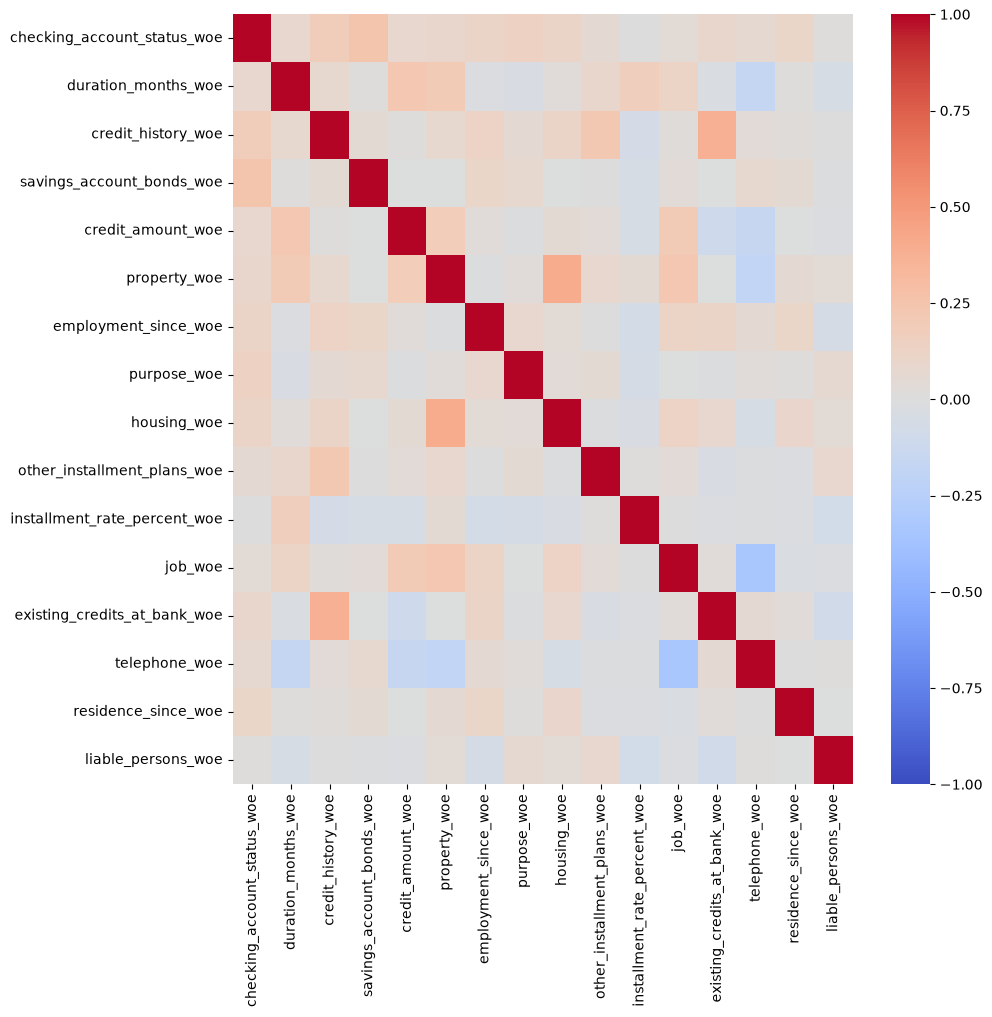

In [45]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_ranked,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

In [46]:
tmp = uti.corr_crit(corr_ranked,.3)

In [47]:
tmp

,var,corr,corr ind
0,checking_account_status_woe,0.243345,False
1,duration_months_woe,0.23402,False
2,credit_history_woe,0.376188,True
3,savings_account_bonds_woe,0.243345,False
4,credit_amount_woe,0.23402,False
5,property_woe,0.403912,True
6,employment_since_woe,0.126969,False
7,purpose_woe,0.137355,False
8,housing_woe,0.403912,True
9,other_installment_plans_woe,0.221045,False


In [48]:
walds = pd.merge(walds, tmp, on="var", how="left")

In [49]:
walds

,var,wald,corr,corr ind
0,checking_account_status_woe,81.374162,0.243345,False
1,duration_months_woe,40.639132,0.23402,False
2,credit_history_woe,40.399187,0.376188,True
3,savings_account_bonds_woe,30.802473,0.243345,False
4,credit_amount_woe,28.469128,0.23402,False
5,property_woe,24.013138,0.403912,True
6,employment_since_woe,21.466149,0.126969,False
7,purpose_woe,19.663274,0.137355,False
8,housing_woe,15.173953,0.403912,True
9,other_installment_plans_woe,14.735023,0.221045,False


## correlation with criteria

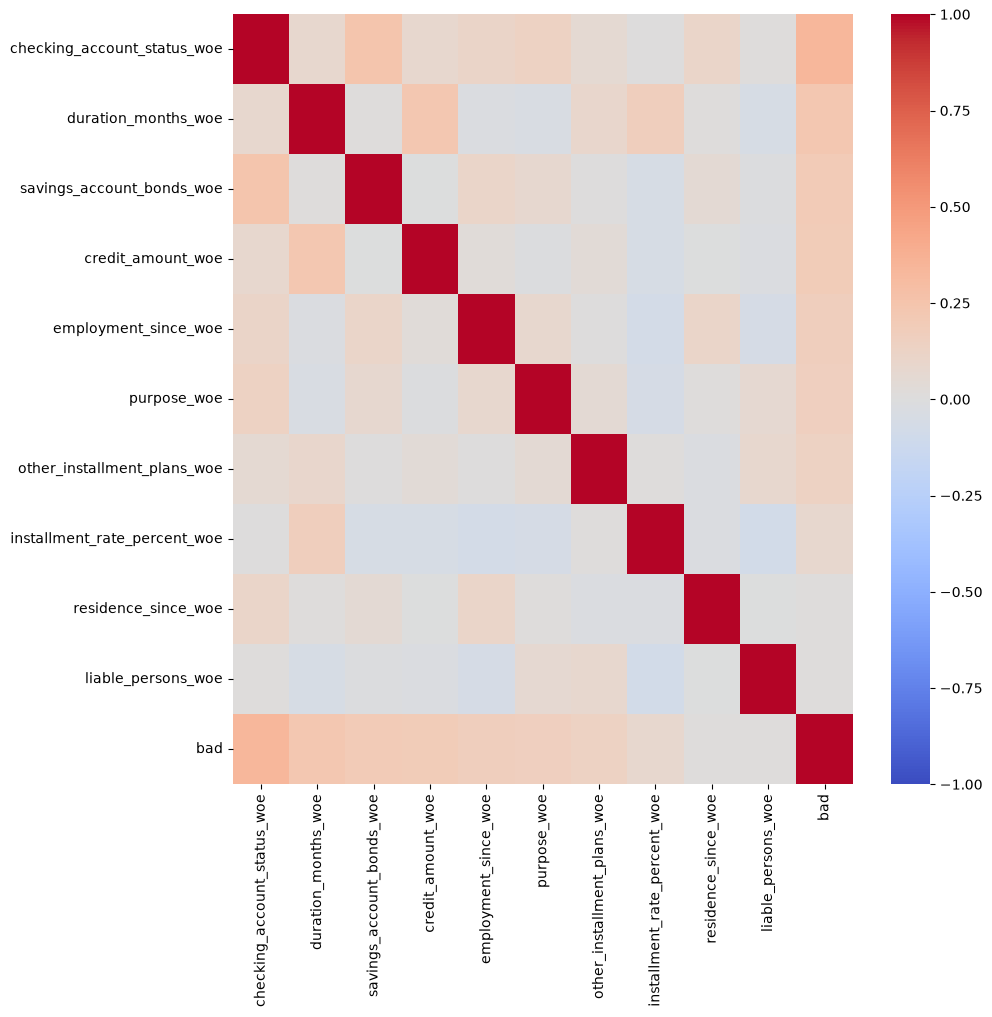

In [50]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    df[walds[walds['corr ind'] == False]['var'].tolist() + ['bad']].corr(),
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

# save wald table

In [51]:
walds.to_pickle("../data/01_df_walds.pkl")